3.2. Linear Regression with Time Series Data


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import pytz
from pymongo import MongoClient
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error


🛠️ Instruction: Locate the IP address of the machine running MongoDB and assign it to the variable host. Make sure to use a string (i.e., wrap the IP in quotes).

⚠️ Note: The IP address is dynamic — it may change every time you start the lab. Always check the current IP before proceeding.


In [3]:
host = "192.135.175.2"

# Prepare Data


## Import


Next, complete the code to create a client to connect to the MongoDB server running at `host` on port `27017`, assign the `"air-quality"` database to `db`, and assign the `"nairobi"` connection to `nairobi`.


In [5]:
client = MongoClient(host="192.135.175.2", port=27017)
db = client["air-quality"]
nairobi = db["nairobi"]

Next, complete the `wrangle` function below so that the `results` from the database query are read into the DataFrame `df`. Be sure that the index of `df` is the `"timestamp"` from the results.


In [24]:
def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    df = pd.DataFrame(results).set_index("timestamp")

    # Localize timeZone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample to 1H window , fill missing value
    df = df["P2"].resample("1H").mean().fillna(method="ffill").to_frame()

    # Add lag feature
    df["P2.L1"] = df["P2"].shift(1)
    
    # Drop NaN rows
    df.dropna(inplace=True)
    
    return df

Next, we Use your wrangle function to read the data from the `nairobi` collection into the DataFrame `df`.


In [25]:
df = wrangle(nairobi)
print(df.shape)
df.head(10)

(2927, 2)


,P2,P2.L1
timestamp,,
2018-09-01 04:00:00+03:00,15.800000,17.541667
2018-09-01 05:00:00+03:00,11.420000,15.800000
2018-09-01 06:00:00+03:00,11.614167,11.420000
2018-09-01 07:00:00+03:00,17.665000,11.614167
2018-09-01 08:00:00+03:00,21.016667,17.665000
2018-09-01 09:00:00+03:00,22.589167,21.016667
2018-09-01 10:00:00+03:00,18.605833,22.589167
2018-09-01 11:00:00+03:00,14.022500,18.605833
2018-09-01 12:00:00+03:00,13.150000,14.022500


In [26]:
# Check your work
assert any([isinstance(df, pd.DataFrame), isinstance(df, pd.Series)])
assert len(df) <= 32907
assert isinstance(df.index, pd.DatetimeIndex)

Next, add to your `wrangle` function so that the `DatetimeIndex` for `df` is localized to the correct timezone, `"Africa/Nairobi"`. After changing the function, rerun the cells above.


In [12]:
df.index.tz_convert("UTC").tz_convert("Africa/Nairobi")[:5]

DatetimeIndex(['2018-09-01 03:00:02.472000+03:00',
               '2018-09-01 03:05:03.941000+03:00',
               '2018-09-01 03:10:04.374000+03:00',
               '2018-09-01 03:15:04.245000+03:00',
               '2018-09-01 03:20:04.869000+03:00'],
              dtype='datetime64[ns, Africa/Nairobi]', name='timestamp', freq=None)

In [27]:
# Check your work
assert df.index.tzinfo == pytz.timezone("Africa/Nairobi")

## Explore


Next, we Create a boxplot of the `"P2"` readings in `df`.


<Axes: title={'center': 'Distribution of PM2.5 Readings'}>

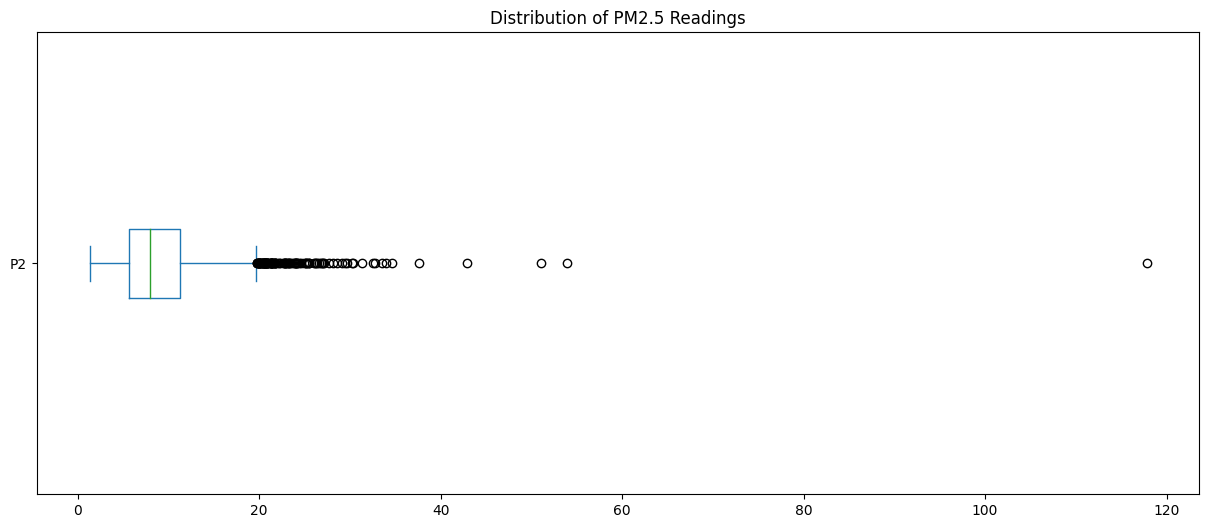

In [28]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(kind="box",vert=False,title = "Distribution of PM2.5 Readings", ax = ax)

Next, add to your `wrangle` function so that all `"P2"` readings above 500 are dropped from the dataset. After changing the function, rerun the cells above.


In [29]:
# Check your work
assert len(df) <= 32906

Next, we Create a time series plot of the `"P2"` readings in `df`.


<Axes: title={'center': 'PM2.5 Time Series'}, xlabel='Time', ylabel='PM2.5'>

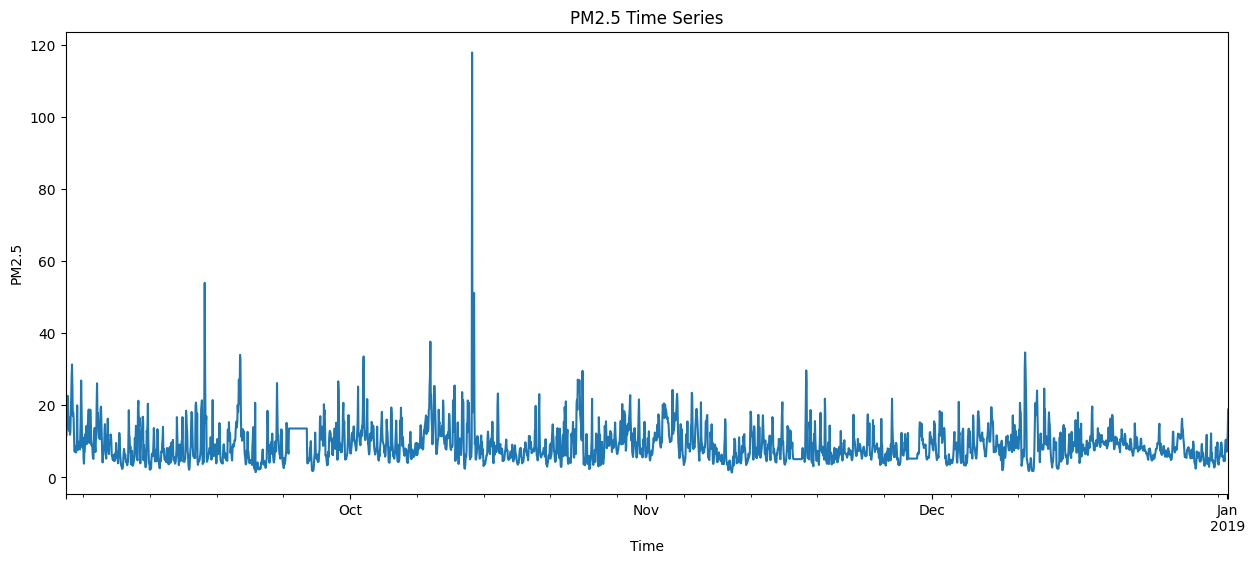

In [30]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].plot(xlabel="Time",ylabel="PM2.5", title= "PM2.5 Time Series", ax=ax)

Next, add to your `wrangle` function to resample `df` to provide the mean `"P2"` reading for each hour. Use a forward fill to impute any missing values. After changing the function, rerun the cells above.


In [21]:
df["P2"].resample("1H").mean().fillna(method="ffill").to_frame().head()

,P2
timestamp,
2018-09-01 03:00:00+03:00,17.541667
2018-09-01 04:00:00+03:00,15.800000
2018-09-01 05:00:00+03:00,11.420000
2018-09-01 06:00:00+03:00,11.614167
2018-09-01 07:00:00+03:00,17.665000


In [31]:
# Check your work
assert len(df) <= 2928

Next, we Plot the rolling average of the `"P2"` readings in `df`. Use a window size of `168` (the number of hours in a week).


In [36]:
df["P2"].rolling(168).mean()

timestamp
2018-09-01 04:00:00+03:00         NaN
2018-09-01 05:00:00+03:00         NaN
2018-09-01 06:00:00+03:00         NaN
2018-09-01 07:00:00+03:00         NaN
2018-09-01 08:00:00+03:00         NaN
                               ...   
2018-12-31 22:00:00+03:00    6.932995
2018-12-31 23:00:00+03:00    6.935927
2019-01-01 00:00:00+03:00    6.938348
2019-01-01 01:00:00+03:00    6.973928
2019-01-01 02:00:00+03:00    7.043333
Freq: H, Name: P2, Length: 2927, dtype: float64

<Axes: title={'center': 'Weekly rolling Average'}, xlabel='timestamp', ylabel='PM2.5'>

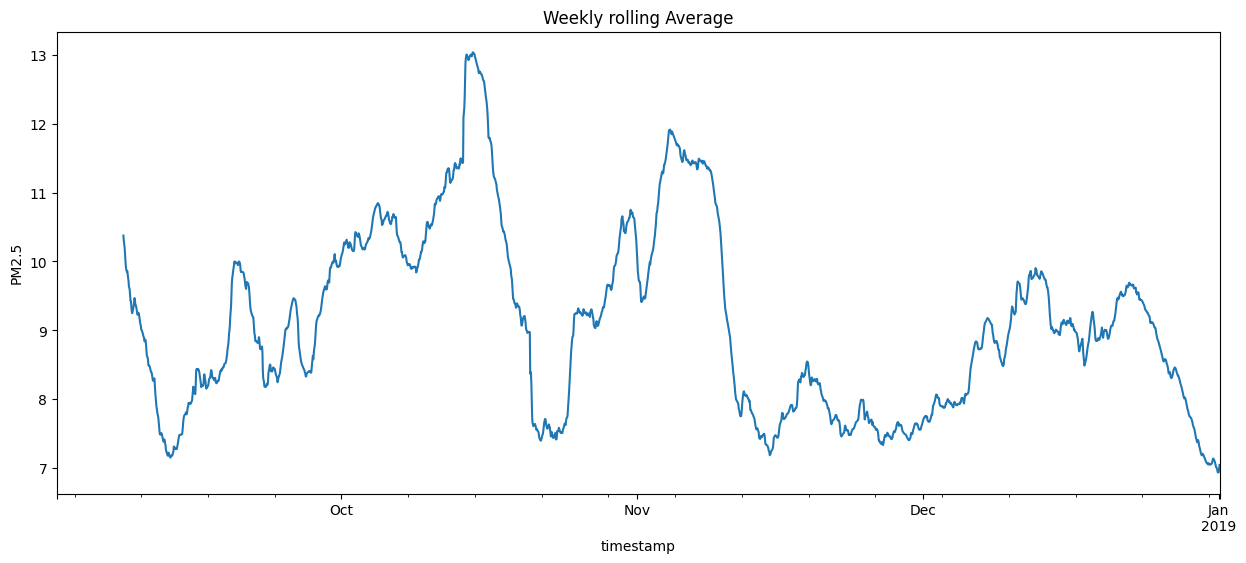

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))
df["P2"].rolling(168).mean().plot(ax=ax,ylabel ="PM2.5", title="Weekly rolling Average")


Next, add to your `wrangle` function to create a column called `"P2.L1"` that contains the mean`"P2"` reading from the previous hour. Since this new feature will create `NaN` values in your DataFrame, be sure to also drop null rows from `df`.


In [39]:
# Check your work
assert len(df) <= 11686
assert df.shape[1] == 2

Next, we Create a correlation matrix for `df`.


In [41]:
df.corr()

,P2,P2.L1
P2,1.000000,0.650679
P2.L1,0.650679,1.000000


Next, we Create a scatter plot that shows PM 2.5 mean reading for each our as a function of the mean reading from the previous hour. In other words, `"P2.L1"` should be on the x-axis, and `"P2"` should be on the y-axis. Don't forget to label your axes!


Text(0.5, 1.0, 'PM2.5 Autocorrelation')

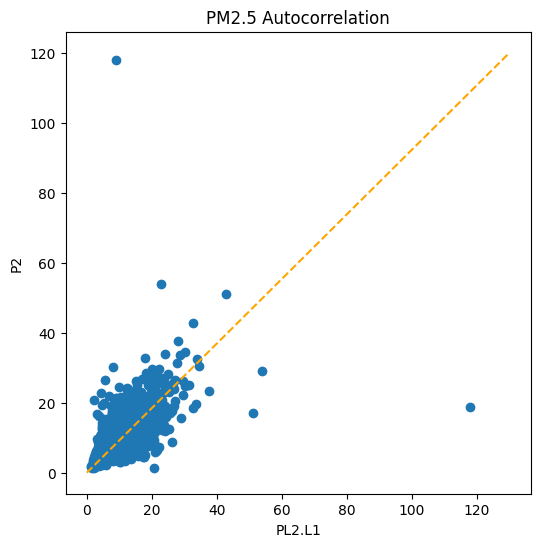

In [48]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x=df["P2.L1"],y=df["P2"])
ax.plot([0,130], [0,120], linestyle="--", color="orange")
plt.xlabel("PL2.L1")
plt.ylabel("P2")
plt.title("PM2.5 Autocorrelation")

## Split


Next, we Split the DataFrame `df` into the feature matrix `X` and the target vector `y`. Your target is `"P2"`.


In [50]:
target = "P2"
y = df[target]
X = df.drop(columns=target)

In [51]:
X.head()

,P2.L1
timestamp,
2018-09-01 04:00:00+03:00,17.541667
2018-09-01 05:00:00+03:00,15.800000
2018-09-01 06:00:00+03:00,11.420000
2018-09-01 07:00:00+03:00,11.614167
2018-09-01 08:00:00+03:00,17.665000


Next, we Split `X` and `y` into training and test sets. The first 80% of the data should be in your training set. The remaining 20% should be in the test set.


In [54]:
cutoff = int(len(X) * 0.8)

X_train, y_train = X.iloc[:cutoff], y.iloc[:cutoff]
X_test, y_test = X.iloc[cutoff:], y.iloc[cutoff:]

In [56]:
len(X_train) + len(X_test) == len(X)

True

# Build Model


## Baseline


Next, we Calculate the baseline mean absolute error for your model.


In [57]:
y_pred_baseline = [y_train.mean()] * len(y_train)
mae_baseline = mean_absolute_error(y_train,y_pred_baseline)

print("Mean P2 Reading:", round(y_train.mean(), 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 9.27
Baseline MAE: 3.89


## Iterate


Next, we Instantiate a [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) model named `model`, and fit it to your training data.


In [58]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

## Evaluate


Next, we Calculate the training and test mean absolute error for your model.


In [60]:
training_mae = mean_absolute_error(y_train, model.predict(X_train))
test_mae = mean_absolute_error(y_test, model.predict(X_test))
print("Training MAE:", round(training_mae, 2))
print("Test MAE:", round(test_mae, 2))

Training MAE: 2.46
Test MAE: 1.8


# Communicate Results


Next, we Extract the intercept and coefficient from your `model`.


In [61]:
intercept = model.intercept_.round(2)
coefficient = model.coef_.round(2)
print(f"P2 = {intercept} + ({coefficient} * P2.L1)")

P2 = 3.36 + ([0.64] * P2.L1)


Next, we Create a DataFrame `df_pred_test` that has two columns: `"y_test"` and `"y_pred"`. The first should contain the true values for your test set, and the second should contain your model's predictions. Be sure the index of `df_pred_test` matches the index of `y_test`.


In [62]:
df_pred_test = pd.DataFrame(
    {
        "y_test": y_test,
        "y_pred": model.predict(X_test)
    }
)
df_pred_test.head()


,y_test,y_pred
timestamp,,
2018-12-07 17:00:00+03:00,7.070000,8.478927
2018-12-07 18:00:00+03:00,8.968333,7.865485
2018-12-07 19:00:00+03:00,11.630833,9.076421
2018-12-07 20:00:00+03:00,11.525833,10.774814
2018-12-07 21:00:00+03:00,9.533333,10.707836


Next, we Create a time series line plot for the values in `test_predictions` using plotly express. Be sure that the y-axis is properly labeled as `"P2"`.


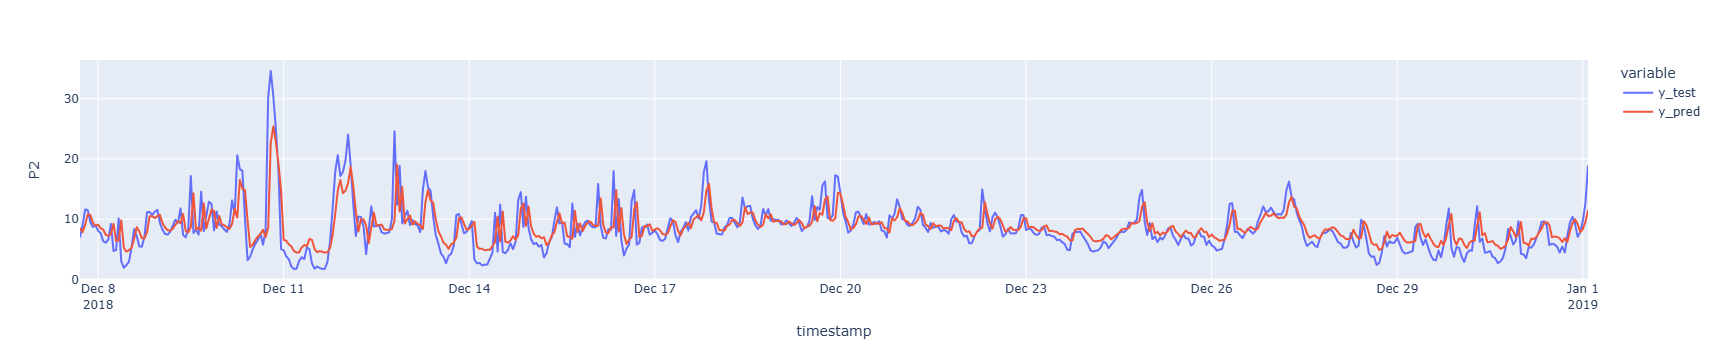

In [64]:
fig = px.line(df_pred_test, labels={"value":"P2"})
fig.show()

---

content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
